# 物流销售综合分析

本 Notebook 使用 pandas 完成数据清洗与规整，使用 Matplotlib 进行可视化。原始数据位于 `E:/animal/data_wuliu.csv`，不会被覆盖。

In [1]:
# 导入处理文件路径的工具。
from pathlib import Path
# 导入 pandas，用来读取和整理表格数据。
import pandas as pd
# 导入正则表达式工具，用于识别金额单位。
import re
# 导入 Matplotlib，用来绘制分析图表。
import matplotlib.pyplot as plt
# 导入项目中复用的指标计算和图片保存函数。
from analysis import DEFAULT_SOURCE, make_kpis, save_figures
# 把 Notebook 当前目录作为结果输出目录。
OUTPUT_DIR = Path.cwd()
# 把生成的图片统一放入 figures 子文件夹。
FIGURE_DIR = OUTPUT_DIR / 'figures'
# 设置表格最多显示 30 列，避免重要字段被隐藏。
pd.set_option('display.max_columns', 30)
# 设置中文字体候选，减少图表中文乱码。
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
# 正常显示坐标轴中的负号。
plt.rcParams['axes.unicode_minus'] = False

## 1. 读取与数据质量概览

In [2]:
# 先读取原始数据，使用 GB18030 编码，并暂时全部按字符串处理。
raw = pd.read_csv(DEFAULT_SOURCE, encoding='gb18030', dtype='string')
# 查看原始数据规模。
print(f'原始数据形状：{raw.shape}')
# 显示原始数据的前五行，帮助初步了解字段内容。
display(raw.head())
# 统计每一列的缺失数量和缺失比例。
missing_report = pd.DataFrame({'缺失数量': raw.isna().sum(), '缺失率': raw.isna().mean()})
# 显示缺失值统计表。
display(missing_report)
# 统计完全重复的记录数量。
duplicate_count = raw.duplicated().sum()
# 输出完全重复记录数量。
print(f'完全重复记录数：{duplicate_count}')

原始数据形状：(1161, 10)


,订单号,订单行,销售时间,交货时间,货品交货状况,货品,货品用户反馈,销售区域,数量,销售金额
0,P096311,10,2016-7-30,2016-9-30,晚交货,货品3,质量合格,华北,2,"1052,75元"
1,P096826,10,2016-8-30,2016-10-30,按时交货,货品3,质量合格,华北,10,"11,50万元"
2,<NA>,20,2016-8-30,2016-10-30,按时交货,货品3,质量合格,华北,10,"11,50万元"
3,P097435,10,2016-7-30,2016-9-30,按时交货,货品1,返修,华南,2,"6858,77元"
4,P097446,60,2016-11-26,2017-1-26,晚交货,货品3,质量合格,华北,15,"129,58元"


,缺失数量,缺失率
订单号,2,0.001723
订单行,0,0.000000
销售时间,0,0.000000
交货时间,0,0.000000
货品交货状况,2,0.001723
货品,0,0.000000
货品用户反馈,0,0.000000
销售区域,0,0.000000
数量,4,0.003445
销售金额,0,0.000000


完全重复记录数：9


## 2. 清洗与字段规整

In [3]:
# 复制原始表格，后续清洗只修改副本，不影响 raw。
data = raw.copy()
# 记录删除重复行前的行数，便于准确统计删除数量。
before_duplicates = len(data)
# 删除完全重复的行，保留每组重复数据的第一行。
data.drop_duplicates(keep='first', inplace=True)
# 计算实际删除的完全重复行数量。
duplicate_rows_removed = before_duplicates - len(data)
# 删除任意字段包含空值的行，保证后续分析使用完整记录。
data.dropna(axis=0, how='any', inplace=True)
# 删除不参与本次分析的订单行列。
data.drop('订单行', axis=1, inplace=True)
# 删除行后重新生成从 0 开始的连续索引。
data.reset_index(drop=True, inplace=True)
# 定义金额转换函数，把带单位的文字金额转换为人民币元。
def convert_amount(value):
    # 把输入转成字符串并去除两端空格。
    text = str(value).strip().replace(' ', '')
    # 识别数字、小数逗号和“元/万元”单位。
    match = re.fullmatch(r'([0-9]+(?:,[0-9]+)?)\s*(元|万元)', text)
    # 无法识别的金额返回缺失值，后面会被删除。
    if not match:
        return float('nan')
    # 逗号改成小数点；万元需要换算成元。
    number = float(match.group(1).replace(',', '.'))
    # 根据单位返回统一的人民币元金额。
    return number * 10000 if match.group(2) == '万元' else number
# 用 map 逐个转换“销售金额”列中的每一个元素。
data['销售金额'] = data['销售金额'].map(convert_amount)
# 删除金额转换失败后新产生的空值。
data.dropna(axis=0, how='any', inplace=True)
# 转换后再次整理索引，保证行号连续。
data.reset_index(drop=True, inplace=True)
# 将“销售时间”列转换为标准的日期时间格式。
data['销售时间'] = pd.to_datetime(data['销售时间'])
# 对每条销售时间应用 lambda 表达式，提取月份数值并创建“月份”列。
data['月份'] = data['销售时间'].apply(lambda x: x.month)
# 将中文列名改成程序统一使用的英文列名，并保留新建的“月份”列。
df = data.rename(columns={'订单号': 'order_id', '销售时间': 'sale_date', '交货时间': 'delivery_date', '货品交货状况': 'delivery_status', '货品': 'product', '货品用户反馈': 'customer_feedback', '销售区域': 'sales_region', '数量': 'quantity', '销售金额': 'sales_amount_cny'}).copy()
# 将交货状态转换为字符串并去除首尾空格，避免同一状态被分成不同类别。
df['delivery_status'] = df['delivery_status'].astype('string').str.strip()
# 创建中文交货状态列，供四个维度分析统一使用。
df['货品交货状况'] = df['delivery_status']
# 创建中文销售区域列，供区域和组合维度分组使用。
df['销售区域'] = df['sales_region']
# 创建中文货品列，供货品和组合维度分组使用。
df['货品'] = df['product']
# 只保留按时交货和晚交货记录，作为四个维度分析的统一数据来源。
delivery_df = df[df['货品交货状况'].isin(['按时交货', '晚交货'])].copy()
# 将销售数量转换为数值类型；无法转换的内容会变成空值。
df['quantity'] = pd.to_numeric(df['quantity'], errors='coerce')
# 再次确保销售金额为数值类型，供均值、标准差等统计计算使用。
df['sales_amount_cny'] = pd.to_numeric(df['sales_amount_cny'], errors='coerce')
# 删除数值转换失败产生的空值，避免后续统计结果受到影响。
df.dropna(subset=['quantity', 'sales_amount_cny'], inplace=True)
# 删除记录后重新生成连续索引。
df.reset_index(drop=True, inplace=True)
# 把销售日期和交货日期转换成日期类型。
df['sale_date'] = pd.to_datetime(df['sale_date'])
# 计算每条记录从销售到交货经过了多少天。
df['delivery_days'] = (pd.to_datetime(df['delivery_date']) - df['sale_date']).dt.days
# 按交货状态判断是否按时交货。
df['is_on_time'] = df['delivery_status'].eq('按时交货').astype('boolean')
# 因为前面已删除异常行，这里把保留下来的记录标记为正常。
df['data_quality_flag'] = '正常'
# 保存清洗前后的数量摘要，供后续展示和导出。
quality = {'raw_rows': len(raw), 'clean_rows': len(df), 'duplicate_rows_removed': duplicate_rows_removed, 'clean_missing': df.isna().sum().to_dict()}
# 查看清洗后的规模、示例、字段类型、缺失值和质量标签。
print(f'清洗后数据形状：{df.shape}')
display(df.head())
display(df.dtypes.to_frame('数据类型'))
display(pd.DataFrame({'缺失数量': df.isna().sum()}))
display(df['data_quality_flag'].value_counts().to_frame('记录数'))

清洗后数据形状：(1146, 16)


,order_id,sale_date,delivery_date,delivery_status,product,customer_feedback,sales_region,quantity,sales_amount_cny,月份,货品交货状况,销售区域,货品,delivery_days,is_on_time,data_quality_flag
0,P096311,2016-07-30,2016-9-30,晚交货,货品3,质量合格,华北,2.0,1052.75,7,晚交货,华北,货品3,62,False,正常
1,P096826,2016-08-30,2016-10-30,按时交货,货品3,质量合格,华北,10.0,115000.00,8,按时交货,华北,货品3,61,True,正常
2,P097435,2016-07-30,2016-9-30,按时交货,货品1,返修,华南,2.0,6858.77,7,按时交货,华南,货品1,62,True,正常
3,P097446,2016-11-26,2017-1-26,晚交货,货品3,质量合格,华北,15.0,129.58,11,晚交货,华北,货品3,61,False,正常
4,P097446,2016-11-26,2017-1-26,晚交货,货品3,拒货,华北,15.0,32.39,11,晚交货,华北,货品3,61,False,正常


,数据类型
order_id,string
sale_date,datetime64[us]
delivery_date,string
delivery_status,string
product,string
customer_feedback,string
sales_region,string
quantity,Float64
sales_amount_cny,float64
月份,int64


,缺失数量
order_id,0
sale_date,0
delivery_date,0
delivery_status,0
product,0
customer_feedback,0
sales_region,0
quantity,0
sales_amount_cny,0
月份,0


,记录数
data_quality_flag,
正常,1146


## 3. 核心指标

In [4]:
# 根据清洗后的明细数据计算订单数、金额、数量和交付等核心指标。
# 计算清洗后的核心业务指标。
# 根据清洗结果计算核心指标。
kpis = make_kpis(df)
# 将指标转换为表格后显示。
display(kpis.to_frame('指标值'))
# 输出删除的完全重复行数量。
print(f"删除重复记录：{quality['duplicate_rows_removed']} 条")
# 输出按时交货率，未知状态不参与计算。
print(f"按时交货率（未知状态不计入）：{kpis['按时交货率']:.2%}")

,指标值
清洗后记录数,1.146000e+03
订单数,8.650000e+02
销售数量合计,8.717550e+04
销售金额合计（元）,1.402118e+06
平均交货天数,7.560646e+01
按时交货率,8.848168e-01


删除重复记录：9 条
按时交货率（未知状态不计入）：88.48%


## 4. 异常值识别

本节不删除异常值，只按以下规则识别并报告：销售金额最小值为 0；销售数量或销售金额的标准差超过均值的 8 倍，且均值大于中位数。

In [5]:
# 选择需要检查异常情况的销售数量和销售金额两列。
outlier_columns = ['quantity', 'sales_amount_cny']
# 计算每列的最小值、均值、中位数和标准差。
outlier_summary = df[outlier_columns].agg(['min', 'mean', 'median', 'std']).T
# 判断销售金额最小值是否为 0。
amount_min_is_zero = outlier_summary.loc['sales_amount_cny', 'min'] == 0
# 判断每列的标准差是否超过均值的 8 倍。
outlier_summary['标准差超过均值8倍'] = outlier_summary['std'] > outlier_summary['mean'] * 8
# 判断每列的均值是否大于中位数。
outlier_summary['均值大于中位数'] = outlier_summary['mean'] > outlier_summary['median']
# 两个条件同时满足时，标记为“标准差过大”异常。
outlier_summary['标准差过大异常'] = outlier_summary['标准差超过均值8倍'] & outlier_summary['均值大于中位数']
# 将标准字段名替换为更易读的中文名称。
outlier_summary.index = ['销售数量', '销售金额（元）']
# 显示异常值识别所依据的统计量和判断结果。
display(outlier_summary)
# 输出销售金额最小值异常的结论。
print(f'销售金额最小值：{outlier_summary.loc["销售金额（元）", "min"]}')
# 根据最小值是否为 0 输出对应的判断。
print(f'最小值异常（销售金额为 0）：{amount_min_is_zero}')
# 输出销售数量的标准差异常判断。
print(f'销售数量标准差过大异常：{outlier_summary.loc["销售数量", "标准差过大异常"]}')
# 输出销售金额的标准差异常判断。
print(f'销售金额标准差过大异常：{outlier_summary.loc["销售金额（元）", "标准差过大异常"]}')

,min,mean,median,std,标准差超过均值8倍,均值大于中位数,标准差过大异常
销售数量,1.0,76.069372,1.000,589.416486,False,True,False
销售金额（元）,0.0,1223.488255,94.765,11145.993359,True,True,True


销售金额最小值：0.0
最小值异常（销售金额为 0）：True
销售数量标准差过大异常：False
销售金额标准差过大异常：True


## 5. 按月配送维度分析

按月份比较按时交货和晚交货数量，计算每个月的按时交货率，用于观察季节变化是否可能影响配送表现。

In [6]:
# 清洗步骤已统一准备好交货状态列和配送分析数据，这里直接使用。
# 按“月份”和“货品交货状况”两个维度分组，并统计每组记录数量。
date1 = delivery_df.groupby(['月份', '货品交货状况']).size()
# 将两层索引展开成表格，使交货状态变成单独的列。
date1 = date1.unstack().fillna(0)
# 若某个月没有按时交货记录，补 0，避免后续计算出现列缺失。
if '按时交货' not in date1.columns:
    date1['按时交货'] = 0
# 若某个月没有晚交货记录，补 0，避免后续计算出现列缺失。
if '晚交货' not in date1.columns:
    date1['晚交货'] = 0
# 计算按时交货率：按时交货数量除以按时交货与晚交货数量之和。
date1['按时交货率'] = date1['按时交货'] / (date1['按时交货'] + date1['晚交货'])
# 将结果显示为百分比格式，便于查看不同月份的配送表现。
display(date1.style.format({'按时交货率': '{:.2%}'}))
# 输出最高按时交货率所在的月份，作为初步观察结果。
print(f'按时交货率最高的月份：{date1["按时交货率"].idxmax()} 月')
# 输出最低按时交货率所在的月份，作为需要重点复核的月份。
print(f'按时交货率最低的月份：{date1["按时交货率"].idxmin()} 月')

货品交货状况,按时交货,晚交货,按时交货率
月份,,,
7,189,13,93.56%
8,218,35,86.17%
9,122,9,93.13%
10,238,32,88.15%
11,101,25,80.16%
12,146,18,89.02%


按时交货率最高的月份：7 月
按时交货率最低的月份：11 月


## 6. 按销售区域维度分析

按销售区域比较按时交货率，并按从高到低排序，用于定位配送服务相对薄弱的区域。

In [7]:
# 清洗步骤已统一准备好销售区域列，这里直接使用。
# 按“销售区域”和“货品交货状况”两个维度分组，并统计每组记录数量。
date2 = delivery_df.groupby(['销售区域', '货品交货状况']).size().unstack().fillna(0)
# 若数据中没有按时交货这一列，补 0，避免后续计算报错。
if '按时交货' not in date2.columns:
    date2['按时交货'] = 0
# 若数据中没有晚交货这一列，补 0，避免后续计算报错。
if '晚交货' not in date2.columns:
    date2['晚交货'] = 0
# 计算各销售区域的按时交货率。
date2['按时交货率'] = date2['按时交货'] / (date2['按时交货'] + date2['晚交货'])
# 按按时交货率从高到低排序，便于比较各区域服务表现。
date2 = date2.sort_values('按时交货率', ascending=False)
# 以百分比格式显示各区域的统计结果。
display(date2.style.format({'按时交货率': '{:.2%}'}))
# 输出按时交货率最低的区域，作为优先关注的服务短板。
print(f'需要优先关注的区域：{date2["按时交货率"].idxmin()}')

货品交货状况,按时交货,晚交货,按时交货率
销售区域,,,
泰国,183,4,97.86%
马来西亚,310,16,95.09%
华南,10,1,90.91%
华北,226,27,89.33%
华东,268,40,87.01%
西北,17,44,27.87%


需要优先关注的区域：西北


## 7. 按货品维度分析

比较不同货品的按时交货率，定位可能存在配送延迟问题的单品。

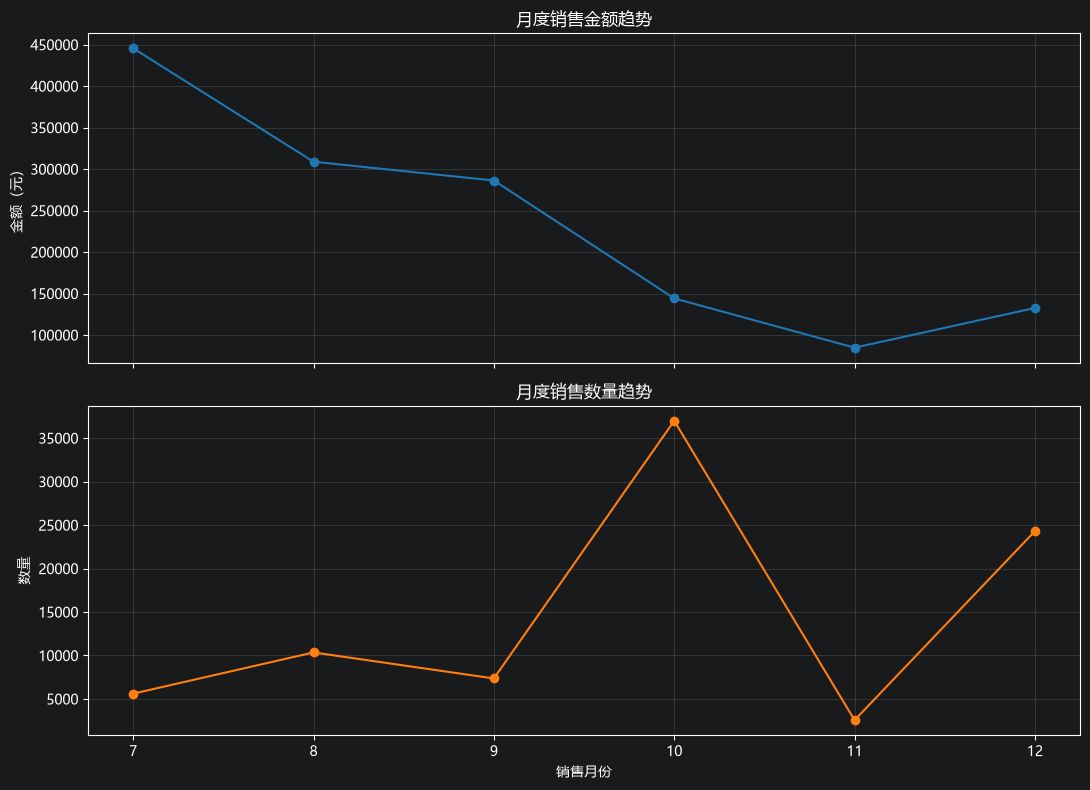

In [8]:
# 按销售月份汇总金额和数量，用于观察业务随时间的变化趋势。
# 按销售月份分组，并汇总每个月的销售金额和数量。
# 按新建的“月份”列分组，汇总每月金额和数量。
monthly = df.groupby('月份', observed=True).agg(
    # 汇总月度销售金额和销售数量。
    sales_amount_cny=('sales_amount_cny', 'sum'), quantity=('quantity', 'sum')
)
# 上图看销售金额，下图看销售数量；共享横轴便于按月份对照。
# 创建上下排列的两个图表。
# 创建上下排列的两个图表。
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
# 在上方图表绘制月度销售金额。
monthly['sales_amount_cny'].plot(ax=axes[0], marker='o', color='#1f77b4', title='月度销售金额趋势')
# 在下方图表绘制月度销售数量。
monthly['quantity'].plot(ax=axes[1], marker='o', color='#ff7f0e', title='月度销售数量趋势')
# 设置坐标轴名称。
axes[0].set_ylabel('金额（元）'); axes[1].set_ylabel('数量'); axes[1].set_xlabel('销售月份')
# 添加浅色网格线，方便比较数据。
for ax in axes: ax.grid(alpha=.25)
# 调整布局并显示图表。
plt.tight_layout(); plt.show()

In [9]:
# 清洗步骤已统一准备好货品列，这里直接使用。
# 按“货品”和“货品交货状况”两个维度分组，并统计每组记录数量。
date3 = delivery_df.groupby(['货品', '货品交货状况']).size().unstack().fillna(0)
# 若没有按时交货列，补 0，避免后续计算报错。
if '按时交货' not in date3.columns:
    date3['按时交货'] = 0
# 若没有晚交货列，补 0，避免后续计算报错。
if '晚交货' not in date3.columns:
    date3['晚交货'] = 0
# 计算各货品的按时交货率。
date3['按时交货率'] = date3['按时交货'] / (date3['按时交货'] + date3['晚交货'])
# 按按时交货率从高到低排序，方便比较不同货品的配送表现。
date3 = date3.sort_values('按时交货率', ascending=False)
# 以百分比格式显示货品维度的统计结果。
display(date3.style.format({'按时交货率': '{:.2%}'}))
# 输出按时交货率最低的货品，作为需要重点关注的单品。
print(f'需要优先关注的货品：{date3["按时交货率"].idxmin()}')

货品交货状况,按时交货,晚交货,按时交货率
货品,,,
货品5,183,4,97.86%
货品6,309,7,97.78%
货品1,27,2,93.10%
货品3,212,26,89.08%
货品2,269,49,84.59%
货品4,14,44,24.14%


需要优先关注的货品：货品4


## 8. 货品与销售区域组合维度分析

同时按货品和销售区域分组，找出具体哪个区域的哪个货品存在最明显的配送问题。

In [10]:
# 按“货品”“销售区域”和“货品交货状况”三个维度分组，并统计每组记录数量。
date4 = delivery_df.groupby(['货品', '销售区域', '货品交货状况']).size().unstack().fillna(0)
# 若没有按时交货列，补 0，避免后续计算报错。
if '按时交货' not in date4.columns:
    date4['按时交货'] = 0
# 若没有晚交货列，补 0，避免后续计算报错。
if '晚交货' not in date4.columns:
    date4['晚交货'] = 0
# 计算每个“货品 + 销售区域”组合的按时交货率。
date4['按时交货率'] = date4['按时交货'] / (date4['按时交货'] + date4['晚交货'])
# 将组合结果按按时交货率从低到高排序，最需要关注的组合排在最上方。
date4 = date4.sort_values('按时交货率', ascending=True)
# 以百分比格式显示交叉维度的统计结果。
display(date4.style.format({'按时交货率': '{:.2%}'}))
# 输出按时交货率最低的货品和销售区域组合。
worst_product, worst_region = date4['按时交货率'].idxmin()
# 用中文提示最需要优先排查的具体问题点。
print(f'需要优先排查的组合：{worst_region}的{worst_product}')

需要优先排查的组合：马来西亚的货品2


In [12]:
# 按销售区域分组，汇总每个区域的销售金额、销售数量、平均交货天数和按时交货率。
region_summary = df.groupby('sales_region', dropna=False, observed=True).agg(
    # 计算每个销售区域的销售金额总和。
    销售金额=('sales_amount_cny', 'sum'),
    # 计算每个销售区域的销售数量总和。
    销售数量=('quantity', 'sum'),
    # 计算每个销售区域的平均交货天数。
    平均交货天数=('delivery_days', 'mean'),
    # 计算每个销售区域的按时交货率。
    按时交货率=('is_on_time', 'mean')
).sort_values('销售金额', ascending=False)
# 按货品分组，汇总每种货品的销售金额和销售数量。
product_summary = df.groupby('product', dropna=False, observed=True).agg(
    # 计算每种货品的销售金额总和。
    销售金额=('sales_amount_cny', 'sum'),
    # 计算每种货品的销售数量总和。
    销售数量=('quantity', 'sum')
).sort_values('销售金额', ascending=False)
# 显示按销售区域汇总后的结果。
display(region_summary)
# 显示按货品汇总后的结果。
display(product_summary)


,销售金额,销售数量,平均交货天数,按时交货率
sales_region,,,,
华北,634322.75,11900.5,76.924901,0.893281
华东,293196.29,53812.0,78.811688,0.87013
华南,245527.74,579.0,69.272727,0.909091
西北,127066.15,5240.0,70.491803,0.278689
马来西亚,71639.35,9911.0,74.187117,0.95092
泰国,30365.26,5733.0,73.058824,0.97861


,销售金额,销售数量
product,,
货品3,520546.32,9073.5
货品1,462150.58,3417.0
货品2,305366.79,55322.0
货品6,59468.85,8401.0
货品5,30365.26,5733.0
货品4,24219.74,5229.0


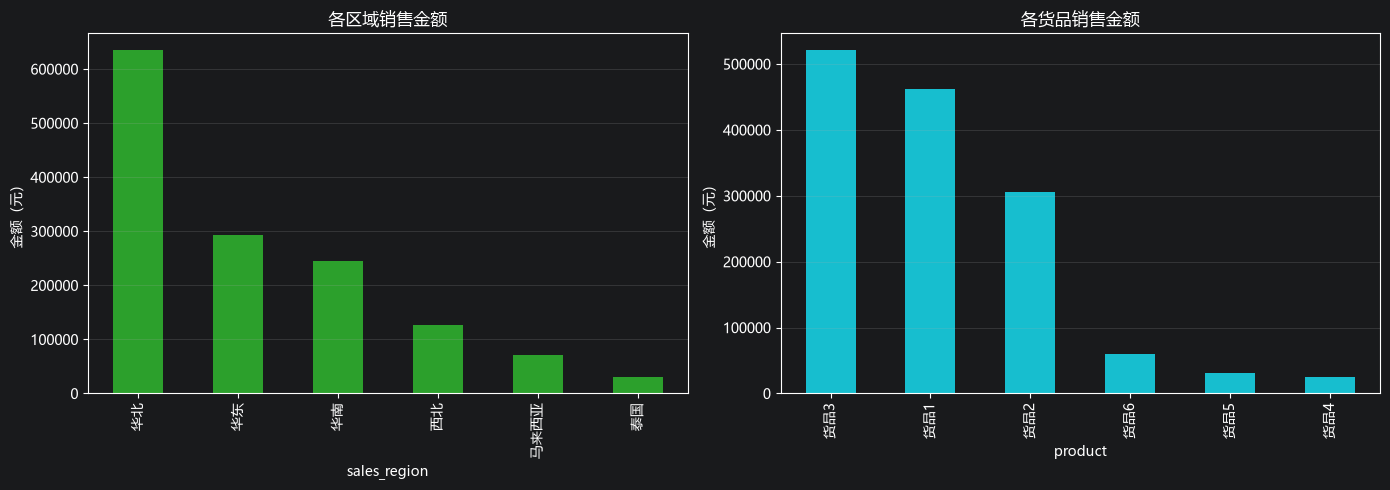

In [13]:
# 用两个柱状图比较不同区域和不同货品的销售金额贡献。
# 创建左右并排的两个图表区域。
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# 在左侧图表绘制各销售区域的销售金额柱状图。
region_summary['销售金额'].plot(kind='bar', ax=axes[0], color='#2ca02c', title='各区域销售金额')
# 在右侧图表绘制各货品的销售金额柱状图。
product_summary['销售金额'].plot(kind='bar', ax=axes[1], color='#17becf', title='各货品销售金额')
# 依次设置两个图表的纵轴名称，并添加浅色水平网格线。
for ax in axes:
    # 设置当前图表的纵轴名称。
    ax.set_ylabel('金额（元）')
    # 添加水平网格线，方便比较柱子的高度。
    ax.grid(axis='y', alpha=0.25)
# 自动调整两个图表之间的间距，避免文字重叠。
plt.tight_layout()
# 显示制作完成的图表。
plt.show()


## 6. 交付与用户反馈

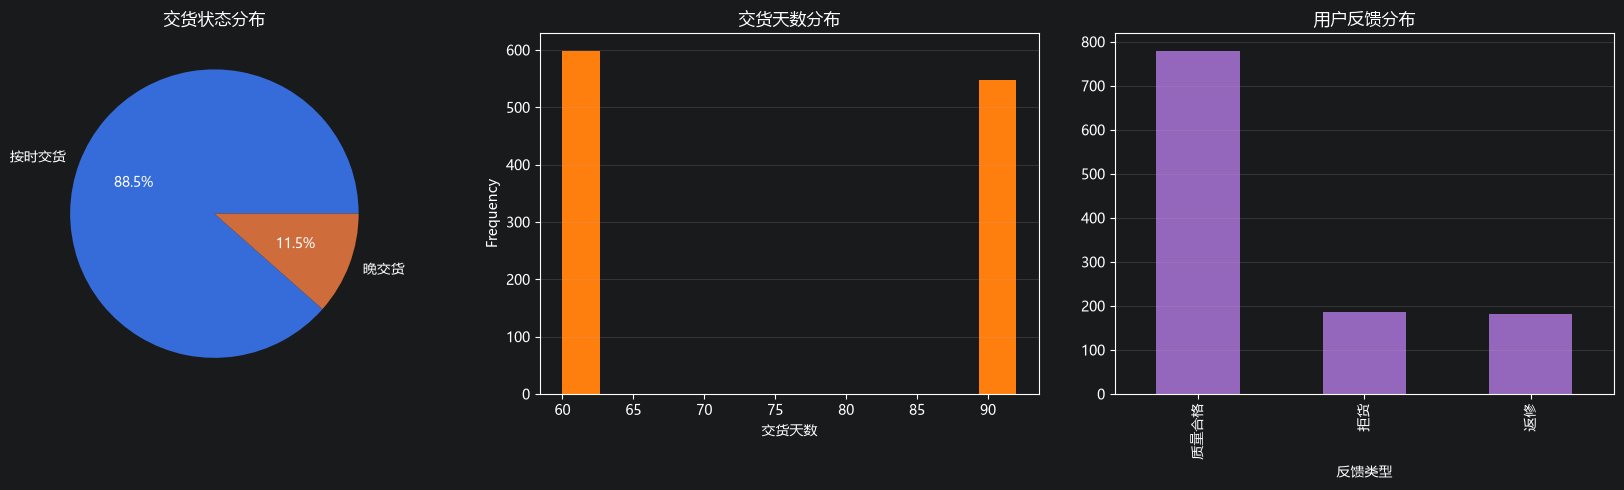

In [14]:
# 同时查看交货状态占比、交货天数分布和用户反馈类别。
# 创建三个并排图表，观察交货和反馈情况。
# 创建三个并排图表。
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
# 统计不同交货状态的数量并绘制饼图。
delivery_counts = df['delivery_status'].value_counts()
delivery_counts.plot(kind='pie', autopct='%.1f%%', ax=axes[0], title='交货状态分布')
# 饼图不需要显示纵轴标签，因此清空纵轴名称。
axes[0].set_ylabel('')
# 删除交货天数中的缺失值并绘制直方图。
delivery_days = df['delivery_days'].dropna()
delivery_days.plot(kind='hist', bins=12, ax=axes[1], color='#ff7f0e', title='交货天数分布')
# 统计用户反馈类别并绘制柱状图。
feedback_counts = df['customer_feedback'].value_counts()
feedback_counts.plot(kind='bar', ax=axes[2], color='#9467bd', title='用户反馈分布')
# 设置直方图和反馈图的横轴名称。
axes[1].set_xlabel('交货天数')
axes[2].set_xlabel('反馈类型')
# 为后两个图表添加水平网格线，方便比较数值。
for ax in axes[1:]:
    ax.grid(axis='y', alpha=0.25)
# 自动调整布局并显示图表。
plt.tight_layout()
plt.show()

## 7. 输出结果

In [15]:
# 将清洗明细、核心指标、缺失值质量报告和分析图表保存到项目目录。
# 保存清洗后的明细数据。
df.to_csv(OUTPUT_DIR / 'data_wuliu_cleaned.csv', index=False, encoding='utf-8-sig')
kpis.rename('value').to_csv(OUTPUT_DIR / 'kpis.csv', encoding='utf-8-sig')
pd.DataFrame({'metric': list(quality['clean_missing']), 'missing_count': list(quality['clean_missing'].values())}).to_csv(OUTPUT_DIR / 'quality_report.csv', index=False, encoding='utf-8-sig')
# 打印实际生成的图片路径，方便在文件夹中找到结果。
saved = save_figures(df, FIGURE_DIR)
print('已输出清洗数据、指标、质量报告和图表：')
for path in saved: print(path)

已输出清洗数据、指标、质量报告和图表：
E:\文档\python_learn\python-2\figures\01_月度销售金额趋势.png
E:\文档\python_learn\python-2\figures\02_区域销售金额.png
E:\文档\python_learn\python-2\figures\03_交货状态分布.png
E:\文档\python_learn\python-2\figures\04_交货天数分布.png
E:\文档\python_learn\python-2\figures\05_用户反馈分布.png
